In [7]:
%load_ext autoreload
%autoreload 2

from Shared.shared import *
from Shared.specific_CNB_sim import *

sim_name = f"SunMod_1k"
# sim_name = f"SunMod_2k"
# sim_name = f"SunMod_5k"
sim_folder = f"sim_output/{sim_name}"

fig_folder = f"figures_local/{sim_name}"
Cl_folder = f"Shared/Cls"
nu_m_range = jnp.load(f"{sim_folder}/neutrino_massrange_eV.npy")
nu_m_picks = jnp.array([0.01, 0.05, 0.1, 0.2, 0.3])*Params.eV
simdata = SimData(sim_folder)


#! Broken halos: either snapshot info missing or anomalous number densities
exclude_nums = jnp.array([
    20,  # halo with missing/broken snapshot info
    23,  # halo with anomalous number densities (~0s on almost all pixels)
    24,  # anomalous "compactified into 1 cell" DM halo
    25,  # anomalous "compactified into 1 cell" DM halo
])
halo_nums = [x for x in range(1, 31) if x not in exclude_nums]


# Fermi-Dirac distribution assumption
dens_folder = f"sim_output/Dopri5_1k"
# note: total densities are computed for length 50 mass range
pix_dens_FD = jnp.load(f"{dens_folder}/pixel_densities.npy")[tuple(halo_nums),...]
tot_dens_FD = jnp.load(f"{dens_folder}/total_densities.npy")[tuple(halo_nums),...]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
days_vecs_dir = f"{sim_folder}/WithSun_vel_CNB_vectors"
fpath = f"{days_vecs_dir}/vectors_day1.npy"
day_v = jnp.load(fpath)[..., 3:][None, ...]
print(day_v.shape)

(1, 768, 1000, 2, 3)


### Precomputations

- Earth velocities from SunEarthGC_frame_coords_local(2024)
- 

### Step-by-step flowchart to arrive at modulations

1. Load neutrino velocity vectors, i.e. output from 1-year simulations.
2. Load Earth velocities.
3. Transform sim velocities into Earth frame
   (issue about boosting to be studied)
4. From here usual process: conversion to momentum, Liouville, integrate.


## Plotting annual modulations

(densities computed in separate .py script)

days_dens shape: (16, 768, 5)


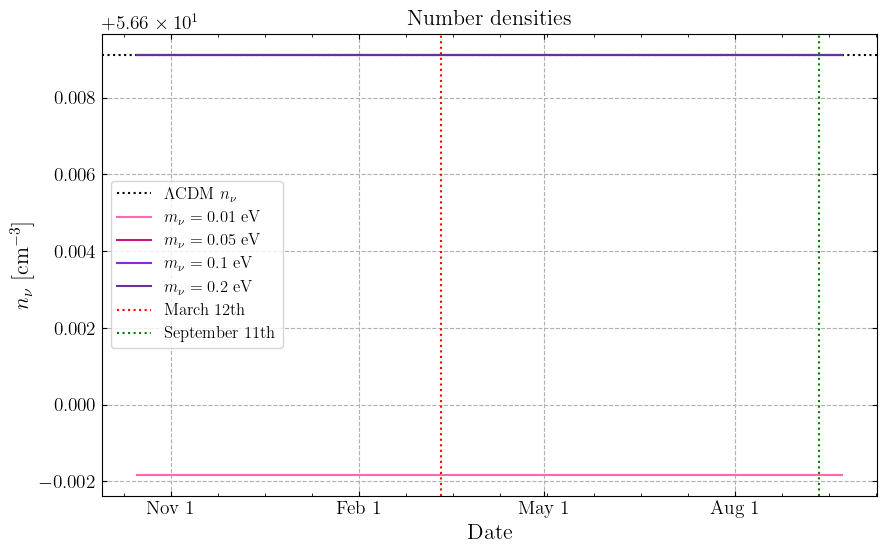

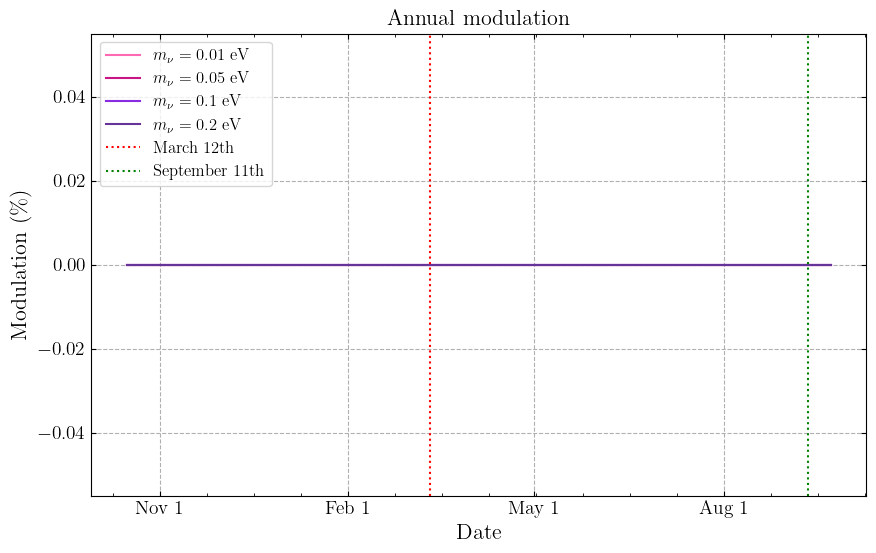

In [9]:
### ======= ###
### Version ###
### ======= ###

# sim_name = f"SunNoG"
sim_name = f"SunMod_1k"
# sim_name = f"SunMod_2k"
# sim_name = f"SunMod_5k"
sim_folder = f"sim_output/{sim_name}"
fig_folder = f"figures_local/{sim_name}"
# prefix = "NoSun"
# prefix = "SunNoDM"
prefix = "Sun+DM"

# Integration over pixels, then summation, just for testing
# suffix = "_FD_PSD_int_pixels"
# suffix = "_FD_PSD_Earth_frame_wrtCNB_int_pixels"

# Integration over merged last axes, i.e. all neutrino in simulation
suffix = "_FD_PSD"
# suffix = "_FD_PSD_Earth_frame_wrtCNB"
# suffix = "_FD_PSD_Earth_frame_wrtMW"
# suffix = "_grav_PSD_Earth_frame_wrtMW_int_pixels"

# note: I think to see if our simulations are saturated enough, the _FD_PSD with the Sun, but not in Earth's frame, should show a modulation as well. This would then mean that our simulations can resolve the daily variability of the Sun's gravitational influence on the CNB density. Right now, we can't see this.

### =========== ###
### Load & Plot ###
### =========== ###

days_nums = jnp.load(f"{sim_folder}/{prefix}_days_nums{suffix}.npy")
days_dens = jnp.load(f"{sim_folder}/{prefix}_days_dens{suffix}.npy")
print(f"days_dens shape: {days_dens.shape}")  # (days, halos, masses)

SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    mode='densities',
    pdf_path=f"{fig_folder}/densities{suffix}",
)
SimPlot.plot_annual_modulations(
    nu_dens_days=days_dens, 
    simulated_days=days_nums,
    nu_m_picks=nu_m_picks,
    start_date_str="09-23",
    pdf_path=f"{fig_folder}/modulation{suffix}",
)

In [9]:
# Directions?:
# - show that modulation curve peak is determined by relative velocity
# - virialisation/isotropy of bound CNB not good assumption?
#   and if all then for small percentage of [0.006, 0.7, 3.9, 12.4, 17.7]
#                                       for [0.01, 0.05, 0.1, 0.2,  0.3] eV

In [ ]:
def Fermi_Dirac_boosted(p_vec, v_boost, args):

    c_unit = args.c#/(args.km/args.s)  # c in our velocity units

    # Get direction of momentum (unit vector)
    p_direction = p_vec / jnp.linalg.norm(p_vec, axis=-1, keepdims=True)

    # Compute Doppler factor
    gamma = 1/jnp.sqrt(1 - jnp.sum(v_boost**2)/c_unit**2)
    doppler_val = gamma * (1 - jnp.sum(v_boost*p_direction, axis=-1)/c_unit)

    # Apply Doppler factor to temperature
    T_effective = args.T_CNB / doppler_val

    p_mag = jnp.linalg.norm(p_vec, axis=-1)

    return 1/(jnp.exp(p_mag/T_effective) + 1)

In [ ]:
def p_orig_from_p_prime(p_prime_vec, v_boost, mass=0):
    
    # Compute gamma factor
    beta_squared = jnp.sum(v_boost**2)#/c**2, but c=1 in our Params units
    gamma = 1/jnp.sqrt(1 - beta_squared)
    
    # Compute energy in boosted frame
    p_prime_mag = jnp.linalg.norm(p_prime_vec, axis=-1)
    E_prime = jnp.sqrt(p_prime_mag**2 + mass**2)
    
    # Get beta hat (unit vector in boost direction)
    beta_hat = v_boost/jnp.linalg.norm(v_boost)
    
    # Compute dot product of beta_hat and p_prime
    beta_dot_p = jnp.sum(beta_hat * p_prime_vec, axis=-1, keepdims=True)
    
    # Compute p in original frame
    p_orig = (p_prime_vec + 
              beta_hat * (gamma-1) * beta_dot_p - 
              gamma * v_boost * E_prime[..., None])
    
    return p_orig

In [ ]:
def transform_CNB_to_Earth_frame(
        p_CNB_vec, v_boost, phase_space_vals):
    """
    Transform phase-space distribution from CNB to Earth frame using general Lorentz transformation.
    """
    # Compute gamma factor
    beta_squared = jnp.sum(v_boost**2)  # assuming natural units, c=1
    gamma = 1/jnp.sqrt(1 - beta_squared)
    
    # Energy in CNB frame (massive particles)
    p_mag_CNB = jnp.linalg.norm(p_CNB_vec, axis=-1, keepdims=True)
    E_CNB = jnp.sqrt(p_mag_CNB**2 + mass**2)
    
    # Compute β·p
    beta_dot_p = jnp.sum(v_boost * p_CNB_vec, axis=-1, keepdims=True)
    
    # Transform to Earth frame using general Lorentz transformation
    p_Earth = (p_CNB_vec + 
               (gamma-1) * beta_dot_p * v_boost/beta_squared - 
               gamma * v_boost * E_CNB)
    
    # Phase space measure transforms with factor 1/(γ(1 - β·p̂))
    p_direction = p_CNB_vec / p_mag_CNB
    doppler_val = gamma * (1 - jnp.sum(v_boost*p_direction, axis=-1))
    measure_factor = 1/doppler_val
    
    # Phase space density is Lorentz invariant
    f_Earth = phase_space_vals
    
    return p_Earth, f_Earth, measure_factor


def number_density_Earth_frame(
        p_CNB_vec, phase_space_vals, v_boost, pix_sr, args):
    """
    Compute number density in Earth frame.
    
    Args:
        p_CNB_vec: Momentum vectors in CNB frame
        phase_space_vals: Values of f(p) in CNB frame
        v_boost: Earth's velocity relative to CNB
        pix_sr: Pixel solid angle
        args: Parameters object
    """
    # Transform to Earth frame
    p_Earth, f_Earth, measure_factor = transform_CNB_to_Earth_frame(
        p_CNB_vec, v_boost, phase_space_vals)
    
    # Compute magnitude of transformed momenta
    p_Earth_mag = jnp.linalg.norm(p_Earth, axis=-1)
    
    # Calculate number density with correct measure
    # p^3 dp dΩ → p^3 dp dΩ / γ(1 - β·p̂)
    y = p_Earth_mag**3 * f_Earth * measure_factor
    x = p_Earth_mag
    n_raw = trap(y, jnp.log(x), axis=-1)
    
    # Multiply by constants and convert units
    n_cm3 = pix_sr * args.g_nu/((2*args.Pi)**3) * n_raw / (1/args.cm**3)
    
    return n_cm3


# For each day:
n_density_Earth = number_density_Earth_frame(
    p_CNB_vec=p_vec_z0_sort,  # your initial momenta
    phase_space_vals=your_f_of_p_values,  # your phase space values
    v_boost=earth_vels[day],
    pix_sr=4*Params.Pi/simdata.Npix,
    args=Params()
)